
Dataset salvo como ..\datasets\vict\10v\data.csv

Número de vítimas por classificação START:
  0 (verde): 986
  1 (amarelo): 1493
  2 (vermelho): 1960
  3 (preto): 561


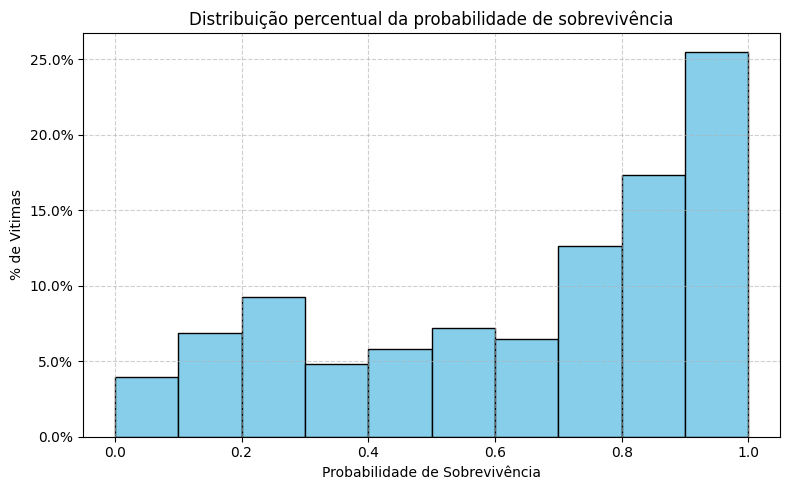

Features utilizadas:
['idade', 'fc', 'fr', 'pas', 'spo2', 'temp', 'pr', 'sg', 'fx', 'queim']

Formato de X: (5000, 10)
Formato de y: (5000,)


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import f1_score, make_scorer, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from collections import Counter
import sys
import os

sys.path.append(os.path.abspath("data_creation"))
from gerar_dados_vitimas import gerar_dataset_vitimas


# Parâmetros do dataset (fixos para o trabalho)
N_VITIMAS = 5000
MEDIA_IDADE = 45
DESVIO_IDADE = 5
TIPO_ACIDENTE = "aereo"
NIVEL_RUIDO = 0.05
SEED_TREINO = 50
SEED_TESTE = 89

# Dataset de treino/validação
df_treino_val = gerar_dataset_vitimas(
    n_vitimas=N_VITIMAS,
    media_idade=MEDIA_IDADE,
    desvio_idade=DESVIO_IDADE,
    tipo_acidente=TIPO_ACIDENTE,
    nivel_ruido=NIVEL_RUIDO,
    seed=SEED_TREINO
)

# variável alvo (target)
y = df_treino_val["tri"]

# colunas proibidas pelo trabalho
colunas_proibidas = ["gcs", "avpu", "tri", "sobr"]

# features (entradas)
X = df_treino_val.drop(columns=colunas_proibidas)

print("Features utilizadas:")
print(list(X.columns))

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

In [2]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import numpy as np

# Parâmetros da MLP

num_params_mlp = 3

layers_escondidos_x = [(10,), (20,), (20,10)]
ativacao_x = ["relu", "relu", "tanh"]
aprendizado_rate_init_x = [0.001, 0.01, 0.001]

# Listas para armazerar resultados
treino_scores_mlp_x = []
vali_scores_mlp_x = []
modelos_mlp_x = []
# Validação cruzada
skf_x = StratifiedKFold( n_splits=5, shuffle=True, random_state=42)



In [3]:
for i in range(num_params_mlp):

    f1_treino_folds_mlp_x = []
    f1_vali_folds_mlp_x = []

    for treino_index_mlp_x, vali_index_mlp_x in skf_x.split(X, y):

        X_treino_fold_mlp_x = X.iloc[treino_index_mlp_x]
        X_vali_fold_mlp_x = X.iloc[vali_index_mlp_x]
        y_treino_fold_mlp_x = y.iloc[treino_index_mlp_x]
        y_vali_fold_mlp_x = y.iloc[vali_index_mlp_x] 

        #normalização
        scaler_x = StandardScaler()
        X_treino_fold_mlp_x = scaler_x.fit_transform(X_treino_fold_mlp_x)
        X_vali_fold_mlp_x = scaler_x.transform(X_vali_fold_mlp_x)

        # Criando modelo MLP com a parametrização i

        mlp_x = MLPClassifier(
            hidden_layer_sizes=layers_escondidos_x[i],
            activation=ativacao_x[i],
            learning_rate_init=aprendizado_rate_init_x[i],
            max_iter=500,
            random_state=42
        )

        # Treinar
        mlp_x.fit(X_treino_fold_mlp_x, y_treino_fold_mlp_x)

        # Previsões
        y_pred_treino_mlp_x = mlp_x.predict(X_treino_fold_mlp_x)
        y_pred_vali_mlp_x = mlp_x.predict(X_vali_fold_mlp_x)

        # f1-score

        f1_treino_mlp_x = f1_score(y_treino_fold_mlp_x, y_pred_treino_mlp_x, average="macro")
        f1_vali_mlp_x = f1_score(y_vali_fold_mlp_x, y_pred_vali_mlp_x, average="macro")

        f1_treino_folds_mlp_x.append(f1_treino_mlp_x)
        f1_vali_folds_mlp_x.append(f1_vali_mlp_x)
    
    treino_scores_mlp_x.append(f1_treino_folds_mlp_x)
    vali_scores_mlp_x.append(f1_vali_folds_mlp_x)
    modelos_mlp_x.append(mlp_x)

    resultados_mlp_x = []

for i in range(num_params_mlp):
    f1_treino_mlp_x = treino_scores_mlp_x[i]
    f1_vali_mlp_x = vali_scores_mlp_x[i]

    media_treino_mlp_x = np.mean(f1_treino_mlp_x)
    media_vali_mlp_x = np.mean(f1_vali_mlp_x)  

    var_treino_mlp_x = np.var(f1_treino_mlp_x)
    var_vali_mlp_x = np.var(f1_vali_mlp_x)

    diff_f1_mlp_x = abs(media_treino_mlp_x - media_vali_mlp_x)
    diff_var_mlp_x = abs(var_treino_mlp_x - var_vali_mlp_x)

    resultados_mlp_x.append({
        "hidden_layers": layers_escondidos_x[i],
        "activation": ativacao_x[i],
        "learning_rate": aprendizado_rate_init_x[i],
        "f1_train_medio": media_treino_mlp_x,
        "f1_val_medio": media_vali_mlp_x,
        "diff_f1": diff_f1_mlp_x,
        "var_train": var_treino_mlp_x,
        "var_val": var_vali_mlp_x,
        "diff_var": diff_var_mlp_x        
    })  

df_resultados_mlp_x = pd.DataFrame(resultados_mlp_x)

display(df_resultados_mlp_x)

c:\Users\DAGEE\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layers,activation,learning_rate,f1_train_medio,f1_val_medio,diff_f1,var_train,var_val,diff_var
0,"(10,)",relu,0.001,0.940510,0.940362,0.000149,0.000005,0.000075,0.000070
1,"(20,)",relu,0.010,0.940564,0.940145,0.000419,0.000005,0.000080,0.000075
2,"(20, 10)",tanh,0.001,0.940724,0.940213,0.000511,0.000006,0.000076,0.000071


In [5]:
df_resultados_mlp_x = df_resultados_mlp_x.sort_values(by="f1_val_medio",ascending=False)

# Selecionar melhor parametrização
melhor_mlp_params_x = df_resultados_mlp_x.iloc[0]

# Criar modelo final MLP
melhor_mlp_modelo_x = MLPClassifier(
    hidden_layer_sizes=melhor_mlp_params_x["hidden_layers"],
    activation=melhor_mlp_params_x["activation"],
    learning_rate_init=melhor_mlp_params_x["learning_rate"],
    max_iter=500,
    random_state=42
)

#normalização antes do treino
scaler_final_x = StandardScaler()
X_scaled_x = scaler_final_x.fit_transform(X)

# Treinar com todos os dados
melhor_mlp_modelo_x.fit(X_scaled_x, y)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",np.float64(0.001)
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
